# Predictions per Camera Angle Notebook

21-06-2026

This notebook is used to take the predictions from an evaluation run and compare the model predictions from each individual camera angle, before they are combined and average. This notebook considers the case of a model that takes one image as input, not the multi-input model.

The following questions are addressed:
- [**How many images do you have?**](##how-many-images-are-there?) Rule of thumb: fewer than ~500 images means YOLO fine-tuning will struggle; you'll need aggressive augmentation.h

Findings from this notebook are added to the documentation in `docs/experiments/index.md`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../outputs/predictions/resnet18.csv")

df

,Unnamed: 0,all_preds,all_skus,all_targets
0,0,263.81190,BLF 2340,270.0
1,1,269.25960,BLF 2340,270.0
2,2,263.18393,BLF 2340,270.0
3,3,272.60257,BLF 2340,270.0
4,4,282.48355,BLF2001,279.0
...,...,...,...,...
303,303,235.16632,BLF2669,235.0
304,304,213.91336,BLF2670,235.0
305,305,240.82901,BLF2670,235.0
306,306,228.50793,BLF2670,235.0


In [10]:
first_angle_preds = list(df['all_preds'][::4])
second_angle_preds = list(df['all_preds'][1::4])
third_angle_preds = list(df['all_preds'][2::4])
fourth_angle_preds = list(df['all_preds'][3::4])

targets = list(df["all_targets"][::4])

print(first_angle_preds)
print(second_angle_preds)
print(third_angle_preds)
print(fourth_angle_preds)

[263.8119, 282.48355, 174.03079, 216.41934, 223.31055, 216.8331, 235.17665, 246.71194, 256.73117, 195.89981, 240.8891, 277.6139, 219.16446, 212.57365, 202.77103, 223.02086, 229.72847, 199.64276, 246.58821, 262.49902, 235.40811, 193.65855, 202.21024, 283.22, 317.80347, 266.7796, 222.93002, 260.52914, 276.45514, 216.3096, 198.95636, 215.58395, 254.05608, 160.63814, 254.95882, 221.79242, 221.80576, 254.26727, 185.23203, 232.00061, 231.06328, 226.49823, 268.2095, 211.695, 248.91246, 219.24281, 157.31337, 159.76865, 218.66887, 242.23595, 164.3865, 210.66766, 169.52365, 240.87552, 242.52608, 240.19748, 164.6766, 278.45364, 329.57928, 418.89743, 392.85898, 209.0166, 313.6986, 233.4179, 227.72986, 260.09882, 259.74823, 281.59305, 366.40417, 202.49684, 301.40662, 181.51694, 169.91519, 207.15555, 301.53992, 233.31212, 213.91336]
[269.2596, 255.92162, 196.8127, 238.45088, 222.3631, 223.26213, 253.66446, 260.32166, 233.1717, 230.5472, 230.28015, 265.3923, 232.09302, 232.4645, 224.1722, 208.61867, 

In [11]:
print(len(first_angle_preds))
print(len(second_angle_preds))
print(len(third_angle_preds))
print(len(fourth_angle_preds))

77
77
77
77


In [15]:
from cattle_weight_regression.evaluation.metrics import compute_all

print(compute_all(np.copy(targets), np.copy(first_angle_preds)))
print(compute_all(np.copy(targets), np.copy(second_angle_preds)))
print(compute_all(np.copy(targets), np.copy(third_angle_preds)))
print(compute_all(np.copy(targets), np.copy(fourth_angle_preds)))

{'mae': 15.64463116883117, 'rmse': 23.317239290003787, 'mape': 6.370113634818887, 'r2': 0.8310730517254252}
{'mae': 15.432456363636364, 'rmse': 22.052967021866877, 'mape': 6.304982618139801, 'r2': 0.8488950354665042}
{'mae': 14.834579220779219, 'rmse': 19.684431127876724, 'mape': 5.901907318167522, 'r2': 0.8796100001371967}
{'mae': 14.720945714285715, 'rmse': 20.077929380764434, 'mape': 5.9788223054143135, 'r2': 0.8747486193056933}


Text(0, 0.5, 'Predicted weights (kg)')

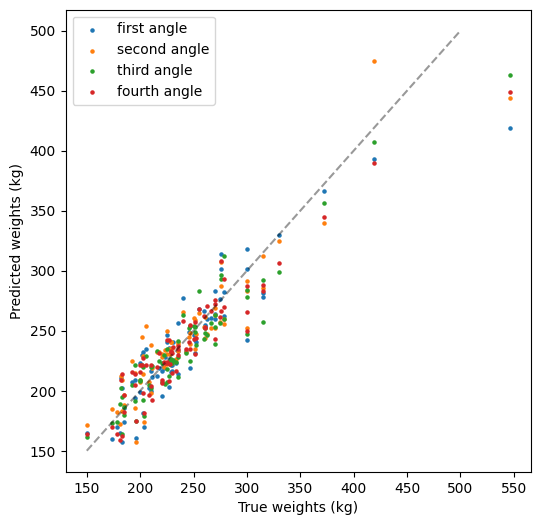

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(targets, first_angle_preds, s=5, label="first angle")
plt.scatter(targets, second_angle_preds, s=5, label="second angle")
plt.scatter(targets, third_angle_preds, s=5, label="third angle")
plt.scatter(targets, fourth_angle_preds, s=5, label="fourth angle")

plt.plot([150,500],[150,500], linestyle='dashed', c='black', alpha=0.4)

plt.legend()

plt.xlabel('True weights (kg)')
plt.ylabel('Predicted weights (kg)')